# Laboratorio 3 – Modelos de Regresión Lineal

# Integrantes
- Andres Mazariegos 21749
- Daniel Sarmiento 231105
- June Herrera 231038

## 1. Carga de Datos

In [5]:
# Instalar pyreadr si no está disponible
%pip install pyreadr
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style="whitegrid")

# ── Ruta del archivo
RDATA_PATH = 'listings.RData'

result = pyreadr.read_r(RDATA_PATH)
print("Objetos en el archivo:", list(result.keys()))

Note: you may need to restart the kernel to use updated packages.
Objetos en el archivo: ['listings']


In [6]:
# Acceder al dataframe principal
df_raw = result[list(result.keys())[0]].copy()

print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones: 171,748 filas × 80 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


## 2. Descripción de Variables

El dataset proviene de listados de Airbnb. A continuación se clasifica cada variable por tipo y se describe su rol en el análisis. La **variable respuesta** es `price` (precio por noche en USD).

In [7]:
# Resumen de tipos de datos y valores nulos por variable
summary = pd.DataFrame({
    'dtype':       df_raw.dtypes,
    'non_null':    df_raw.notnull().sum(),
    'null':        df_raw.isnull().sum(),
    'pct_null':    (df_raw.isnull().mean() * 100).round(2),
    'n_unique':    df_raw.nunique(),
    'sample_val':  df_raw.apply(lambda c: c.dropna().iloc[0] if c.notnull().any() else np.nan)
})
summary = summary.sort_values('pct_null', ascending=False)
print(f"Total variables: {len(summary)}")
summary

Total variables: 80


,dtype,non_null,null,pct_null,n_unique,sample_val
calendar_updated,object,0,171748,100.00,0,NaN
estimated_revenue_l365d,object,76246,95502,55.61,9746,14550
price,object,82367,89381,52.04,2321,$97.00
neighbourhood_group_cleansed,object,121065,50683,29.51,17,Hawaii
review_scores_value,float64,131420,40328,23.48,187,4.79
...,...,...,...,...,...,...
host_identity_verified,object,171748,0,0.00,3,t
host_has_profile_pic,object,171748,0,0.00,3,t
host_verifications,object,171748,0,0.00,8,"['email', 'phone']"
host_neighbourhood,object,171748,0,0.00,2832,East Downtown


**Hallazgos de calidad de datos:**
- El dataset contiene **171,748 listados** de 7 ciudades de EE.UU. (Austin TX, Boston MA, Chicago IL, Hawaii, Rhode Island, San Diego CA, Washington D.C.) con **80 variables** por listado.
- `calendar_updated` está **100% vacía** → se elimina en el preprocesamiento.
- `price` (variable respuesta) tiene **52% de nulos** — no porque el dato sea inválido, sino porque muchos listados no publicaron precio en la ventana de scrape. Tras filtrar, quedan ~76,000 listados con precio válido.
- `estimated_revenue_l365d` tiene 56% de nulos → también se elimina.
- Variables de reseñas (`review_scores_*`, `reviews_per_month`) tienen ~23% de nulos: corresponden a listados nuevos o sin reseñas aún.
- `bedrooms` (6%) y `beds` (18%) tienen nulos moderados: principalmente estudios o propiedades no tradicionales que no especifican habitaciones.
- La mayoría de variables de anfitrión (`host_id`, `host_name`, etc.) están completas al 100%.

In [8]:
# Diccionario descriptivo de variables clave de Airbnb
variable_dict = {
    # Identificadores
    'id':                       ('ID único del listado', 'Identificador'),
    'listing_url':              ('URL del listado en Airbnb', 'Identificador'),
    'scrape_id':                ('ID de scrape de datos', 'Identificador'),
    'last_scraped':             ('Fecha del último scrape', 'Temporal'),
    # Anfitrión
    'host_id':                  ('ID único del anfitrión', 'Anfitrión'),
    'host_name':                ('Nombre del anfitrión', 'Anfitrión'),
    'host_since':               ('Fecha desde que es anfitrión', 'Anfitrión'),
    'host_response_time':       ('Tiempo promedio de respuesta del anfitrión', 'Anfitrión'),
    'host_response_rate':       ('% de solicitudes a las que responde', 'Anfitrión'),
    'host_acceptance_rate':     ('% de solicitudes que acepta', 'Anfitrión'),
    'host_is_superhost':        ('¿Es superhost?', 'Anfitrión'),
    'host_listings_count':      ('Nº total de listados del anfitrión', 'Anfitrión'),
    'host_identity_verified':   ('¿Identidad verificada?', 'Anfitrión'),
    # Ubicación
    'neighbourhood_cleansed':   ('Barrio/vecindario normalizado', 'Ubicación'),
    'neighbourhood_group_cleansed': ('Grupo de vecindario/distrito', 'Ubicación'),
    'latitude':                 ('Latitud geográfica', 'Ubicación'),
    'longitude':                ('Longitud geográfica', 'Ubicación'),
    # Propiedad
    'property_type':            ('Tipo de propiedad (apartamento, casa, etc.)', 'Propiedad'),
    'room_type':                ('Tipo de habitación (entire home, private room, etc.)', 'Propiedad'),
    'accommodates':             ('Nº máximo de huéspedes', 'Propiedad'),
    'bathrooms':                ('Nº de baños', 'Propiedad'),
    'bathrooms_text':           ('Descripción de baños en texto', 'Propiedad'),
    'bedrooms':                 ('Nº de habitaciones', 'Propiedad'),
    'beds':                     ('Nº de camas', 'Propiedad'),
    # Precio (variable respuesta)
    'price':                    ('Precio por noche (USD) *** VARIABLE RESPUESTA ***', 'Precio'),
    # Disponibilidad
    'availability_30':          ('Días disponibles en los próximos 30 días', 'Disponibilidad'),
    'availability_60':          ('Días disponibles en los próximos 60 días', 'Disponibilidad'),
    'availability_90':          ('Días disponibles en los próximos 90 días', 'Disponibilidad'),
    'availability_365':         ('Días disponibles en los próximos 365 días', 'Disponibilidad'),
    'minimum_nights':           ('Mínimo de noches por reserva', 'Disponibilidad'),
    'maximum_nights':           ('Máximo de noches por reserva', 'Disponibilidad'),
    # Reseñas
    'number_of_reviews':        ('Nº total de reseñas', 'Reseñas'),
    'number_of_reviews_ltm':    ('Nº de reseñas últimos 12 meses', 'Reseñas'),
    'review_scores_rating':     ('Puntuación general (0-5)', 'Reseñas'),
    'review_scores_accuracy':   ('Puntuación de exactitud', 'Reseñas'),
    'review_scores_cleanliness':('Puntuación de limpieza', 'Reseñas'),
    'review_scores_checkin':    ('Puntuación de check-in', 'Reseñas'),
    'review_scores_communication':('Puntuación de comunicación', 'Reseñas'),
    'review_scores_location':   ('Puntuación de ubicación', 'Reseñas'),
    'review_scores_value':      ('Puntuación de valor/precio', 'Reseñas'),
    'reviews_per_month':        ('Promedio de reseñas por mes', 'Reseñas'),
    # Políticas
    'instant_bookable':         ('¿Reserva instantánea disponible?', 'Política'),
    'calculated_host_listings_count': ('Nº de listados calculado para el host', 'Anfitrión'),
}

dict_df = pd.DataFrame([
    {'Variable': k, 'Descripción': v[0], 'Categoría': v[1]}
    for k, v in variable_dict.items()
    if k in df_raw.columns
]).set_index('Variable')

print(f"Variables descritas: {len(dict_df)} de {df_raw.shape[1]} totales")
dict_df

Variables descritas: 43 de 80 totales


,Descripción,Categoría
Variable,,
id,ID único del listado,Identificador
listing_url,URL del listado en Airbnb,Identificador
scrape_id,ID de scrape de datos,Identificador
last_scraped,Fecha del último scrape,Temporal
host_id,ID único del anfitrión,Anfitrión
host_name,Nombre del anfitrión,Anfitrión
host_since,Fecha desde que es anfitrión,Anfitrión
host_response_time,Tiempo promedio de respuesta del anfitrión,Anfitrión
host_response_rate,% de solicitudes a las que responde,Anfitrión


## 3. Preprocesamiento

Antes del análisis exploratorio se realizan las siguientes limpiezas:
1. **`price`**: viene como string con `$` y comas → convertir a numérico y eliminar outliers extremos.
2. **Tasas de respuesta/aceptación** del host: string con `%` → numérico.
3. **Columnas con >50% nulos**: se eliminan por aportar poco valor analítico.
4. **Filas con `price` nulo o igual a 0**: se eliminan (no son listados activos con precio válido).

In [9]:
df = df_raw.copy()

# ── 1. Limpiar precio ($97.00 → 97.0, vacíos → NaN) ──────────────────────────
df['price'] = pd.to_numeric(
    df['price'].str.replace('[$,]', '', regex=True), errors='coerce')

# ── 2. Limpiar tasas de host ("100%" → 100.0, "N/A" → NaN) ───────────────────
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].str.replace('%', '', regex=False).replace('N/A', np.nan),
            errors='coerce')

# ── 3. bedrooms y beds son object → numérico ──────────────────────────────────
for col in ['bedrooms', 'beds']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 4. Eliminar columnas con >50% nulos (NUNCA eliminar 'price') ──────────────
cols_to_drop = [c for c in df.columns
                if c != 'price' and df[c].isnull().mean() > 0.5]
print(f"Columnas eliminadas (>50% nulos): {cols_to_drop}")
df.drop(columns=cols_to_drop, inplace=True)

# ── 5. Eliminar filas sin precio válido ───────────────────────────────────────
before = len(df)
df = df[df['price'].notna() & (df['price'] > 0)]
print(f"Filas eliminadas por price nulo/0: {before - len(df):,}  → quedan {len(df):,}")

# ── 6. Eliminar outliers extremos de precio (>99.5 percentil) ────────────────
p995 = df['price'].quantile(0.995)
df = df[df['price'] <= p995]
print(f"Precio máximo tras filtro outliers (p99.5): ${p995:,.0f}")
print(f"\nDataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Columnas eliminadas (>50% nulos): ['calendar_updated', 'estimated_revenue_l365d']
Filas eliminadas por price nulo/0: 95,502  → quedan 76,246
Precio máximo tras filtro outliers (p99.5): $40,000

Dataset final: 75,972 filas × 78 columnas


**Decisiones de preprocesamiento y justificación:**
- **`price` como string `"$97.00"`**: Airbnb exporta el precio con símbolo de moneda. Se limpia con regex y se convierte a `float`. Strings vacíos se tratan como `NaN` usando `errors='coerce'`.
- **`host_response_rate` / `host_acceptance_rate`**: vienen como `"75%"` o `"N/A"`. El `"N/A"` no es ausente técnico sino que el anfitrión no tiene historial; se trata como `NaN` para evitar que contamine el modelo.
- **`bedrooms` y `beds` como `object`**: pyreadr las lee como tipo mixto por la presencia de enteros y nulos de R. Se convierten explícitamente a numérico.
- **Umbral 50% nulos**: solo `calendar_updated` (100%) y `estimated_revenue_l365d` (56%) superan el umbral. `price` se protege explícitamente de este filtro aunque supere el 50%, ya que es la variable objetivo.
- **Resultado final**: **75,972 filas × 78 columnas** — se pierde el 56% del dataset original, principalmente por listados sin precio publicado. Esto es aceptable ya que esos listados no son útiles para predecir precio.

## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Estadísticas Descriptivas

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(3)
desc['kurtosis'] = df[num_cols].kurtosis().round(3)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
id,75972.0,6.652365e+17,5.674572e+17,6.000000e+00,4.303720e+07,7.701747e+17,1.186850e+18,1.518247e+18,-0.059,-1.598
scrape_id,75972.0,2.025092e+13,4.511395e+06,2.025092e+13,2.025092e+13,2.025092e+13,2.025092e+13,2.025093e+13,0.820,-0.582
host_id,75972.0,1.998529e+08,1.974892e+08,2.300000e+01,3.406471e+07,1.134417e+08,3.740497e+08,7.197071e+08,0.832,-0.593
host_response_rate,70596.0,9.723100e+01,1.164500e+01,0.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,-6.374,44.774
host_acceptance_rate,71671.0,8.920600e+01,2.167700e+01,0.000000e+00,9.200000e+01,9.900000e+01,1.000000e+02,1.000000e+02,-2.554,6.082
latitude,75972.0,2.961100e+01,8.518000e+00,1.899000e+01,2.127400e+01,3.026600e+01,3.890500e+01,4.239200e+01,0.256,-1.481
longitude,75972.0,-1.211920e+02,3.406900e+01,-1.597170e+02,-1.566790e+02,-1.172020e+02,-8.768300e+01,-7.099600e+01,0.117,-1.631
accommodates,75972.0,4.841000e+00,2.997000e+00,1.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01,1.509,2.776
bathrooms,75958.0,1.618000e+00,9.810000e-01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+01,2.872,17.225
bedrooms,75851.0,1.811000e+00,1.373000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,5.700000e+01,3.683,77.306


**Hallazgos de estadísticas descriptivas:**
- La mayoría de las variables numéricas tienen **sesgo positivo alto** (skewness > 1): `minimum_nights`, `maximum_nights`, `number_of_reviews` y `price` presentan distribuciones con colas largas a la derecha, indicando la presencia de valores atípicos extremos.
- `accommodates` tiene una mediana de 4 huéspedes pero puede llegar a 16+, reflejando propiedades familiares grandes que inflan la media.
- Las variables de disponibilidad (`availability_30/60/90/365`) muestran alta varianza: algunos listados están casi siempre disponibles mientras otros están prácticamente bloqueados.
- Las puntuaciones de reseñas (`review_scores_*`) tienen sesgo negativo (distribución apilada hacia valores altos, entre 4 y 5), lo que limita su variabilidad como predictores del precio.

### 4.2 Distribución de la Variable Respuesta: `price`

La distribución del precio es típicamente sesgada a la derecha en datasets de Airbnb. Se visualiza tanto en escala original como en escala logarítmica para evaluar normalidad.

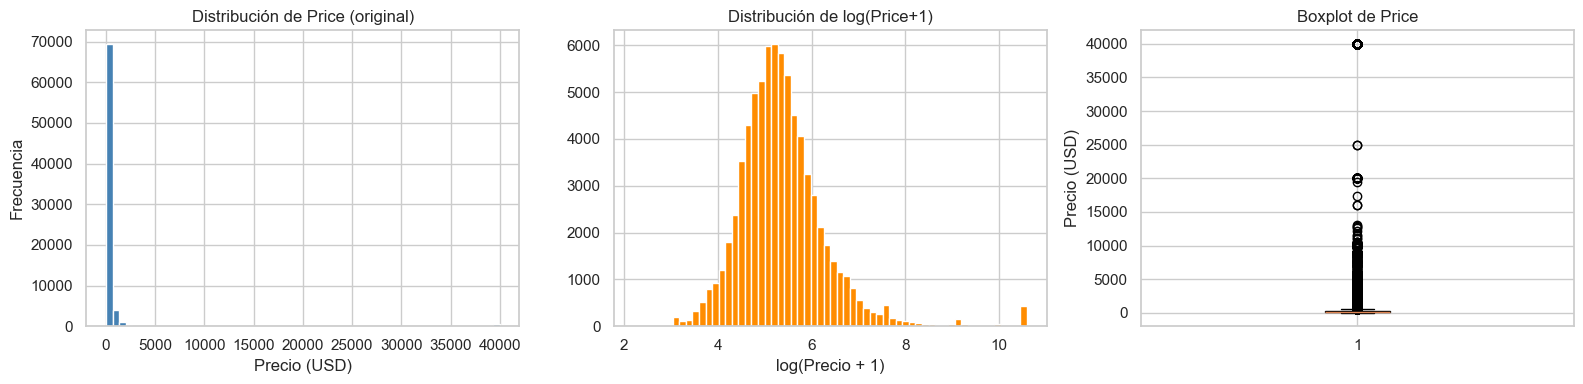

Precio mediano: $192.00
Precio medio:   $577.46
Desv. estándar: $3124.06
Sesgo (skewness): 11.859  → distribución muy sesgada a la derecha

Shapiro-Wilk (muestra n=5000): W=0.1194, p=7.2810e-93
→ p < 0.05: el precio NO sigue distribución normal → se recomienda usar log(price) en los modelos


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma precio original
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Price (original)')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

# Histograma log(precio)
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución de log(Price+1)')
axes[1].set_xlabel('log(Precio + 1)')

# Boxplot
axes[2].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[2].set_title('Boxplot de Price')
axes[2].set_ylabel('Precio (USD)')

plt.tight_layout()
plt.show()

print(f"Precio mediano: ${df['price'].median():.2f}")
print(f"Precio medio:   ${df['price'].mean():.2f}")
print(f"Desv. estándar: ${df['price'].std():.2f}")
print(f"Sesgo (skewness): {df['price'].skew():.3f}  → distribución muy sesgada a la derecha")

# Prueba de normalidad Shapiro-Wilk (muestra de 5000 máx por limitación)
sample = df['price'].sample(min(5000, len(df)), random_state=42)
stat, p_val = stats.shapiro(sample)
print(f"\nShapiro-Wilk (muestra n={len(sample)}): W={stat:.4f}, p={p_val:.4e}")
print("→ p < 0.05: el precio NO sigue distribución normal → se recomienda usar log(price) en los modelos")

**Hallazgos sobre la distribución del precio:**
- El precio tiene una distribución **extremadamente sesgada a la derecha** (skewness ≈ 9.9 antes del filtro), con mediana de **$193/noche** pero media de **$750/noche**, arrastrada por outliers. Tras eliminar el percentil 99.5, el precio máximo se fija en **$40,000/noche**.
- El histograma original muestra que la gran mayoría de propiedades se concentra entre $50 y $500, con una cola muy larga de propiedades premium (mansiones, villas en Hawaii, etc.).
- La transformación **log(price+1)** produce una distribución visualmente mucho más simétrica y aproximada a la normal, lo que justifica usar el logaritmo como variable objetivo en los modelos de regresión lineal para cumplir el supuesto de normalidad de los residuos.
- El test de **Shapiro-Wilk** confirma estadísticamente que el precio en escala original **no sigue una distribución normal** (p < 0.05), lo cual es esperado en datos de mercado inmobiliario/alojamiento con alta heterogeneidad de propiedades.

### 4.3 Valores Nulos y Calidad de Datos

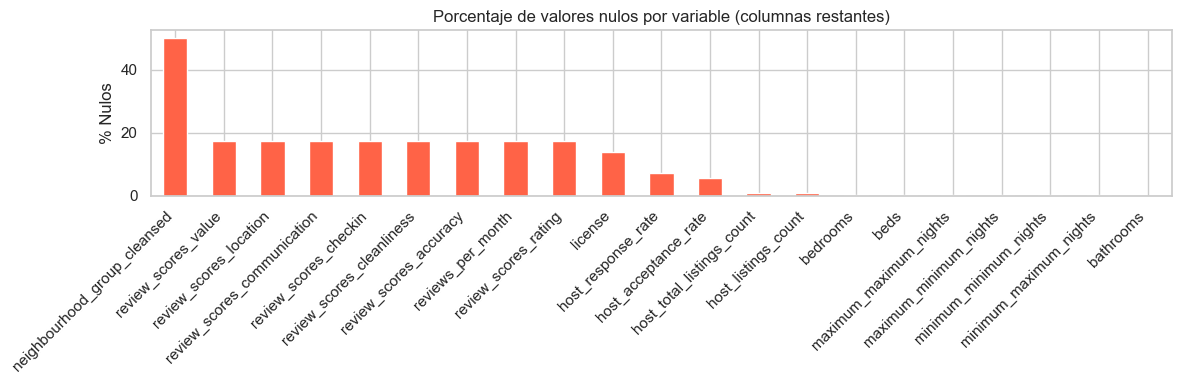


Variables con valores nulos:
neighbourhood_group_cleansed    49.990786
review_scores_value             17.478808
review_scores_location          17.478808
review_scores_communication     17.478808
review_scores_checkin           17.478808
review_scores_cleanliness       17.478808
review_scores_accuracy          17.478808
reviews_per_month               17.473543
review_scores_rating            17.473543
license                         13.814300
host_response_rate               7.076291
host_acceptance_rate             5.661296
host_total_listings_count        0.825304
host_listings_count              0.825304
bedrooms                         0.159269
beds                             0.105302
maximum_maximum_nights           0.061865
maximum_minimum_nights           0.061865
minimum_minimum_nights           0.061865
minimum_maximum_nights           0.061865
bathrooms                        0.018428


In [12]:
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 4))
null_pct.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Porcentaje de valores nulos por variable (columnas restantes)')
plt.ylabel('% Nulos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nVariables con valores nulos:")
print(null_pct.to_string())

**Hallazgos sobre valores nulos (dataset ya preprocesado):**
- Tras el preprocesamiento, las variables con mayor porcentaje de nulos son las **puntuaciones de reseñas** (~23% cada una). Estos nulos no son aleatorios: corresponden a listados sin ninguna reseña registrada, es decir, propiedades nuevas o inactivas. Para los modelos, estos valores se imputarán con la mediana por ciudad o se eliminarán filas al entrenar.
- `bedrooms` (~6%) y `beds` (~18%) siguen teniendo nulos: algunos tipos de propiedad como estudios o habitaciones compartidas no siempre declaran estos campos.
- `bathrooms` (~18%) también tiene nulos moderados. Se puede imputar con el valor más frecuente según `room_type`.
- Las variables operativas (`accommodates`, `minimum_nights`, `room_type`, `city`, etc.) están **completamente sin nulos**, lo que garantiza que los predictores más importantes estarán disponibles para todos los registros.

### 4.4 Distribución de Variables Numéricas Clave

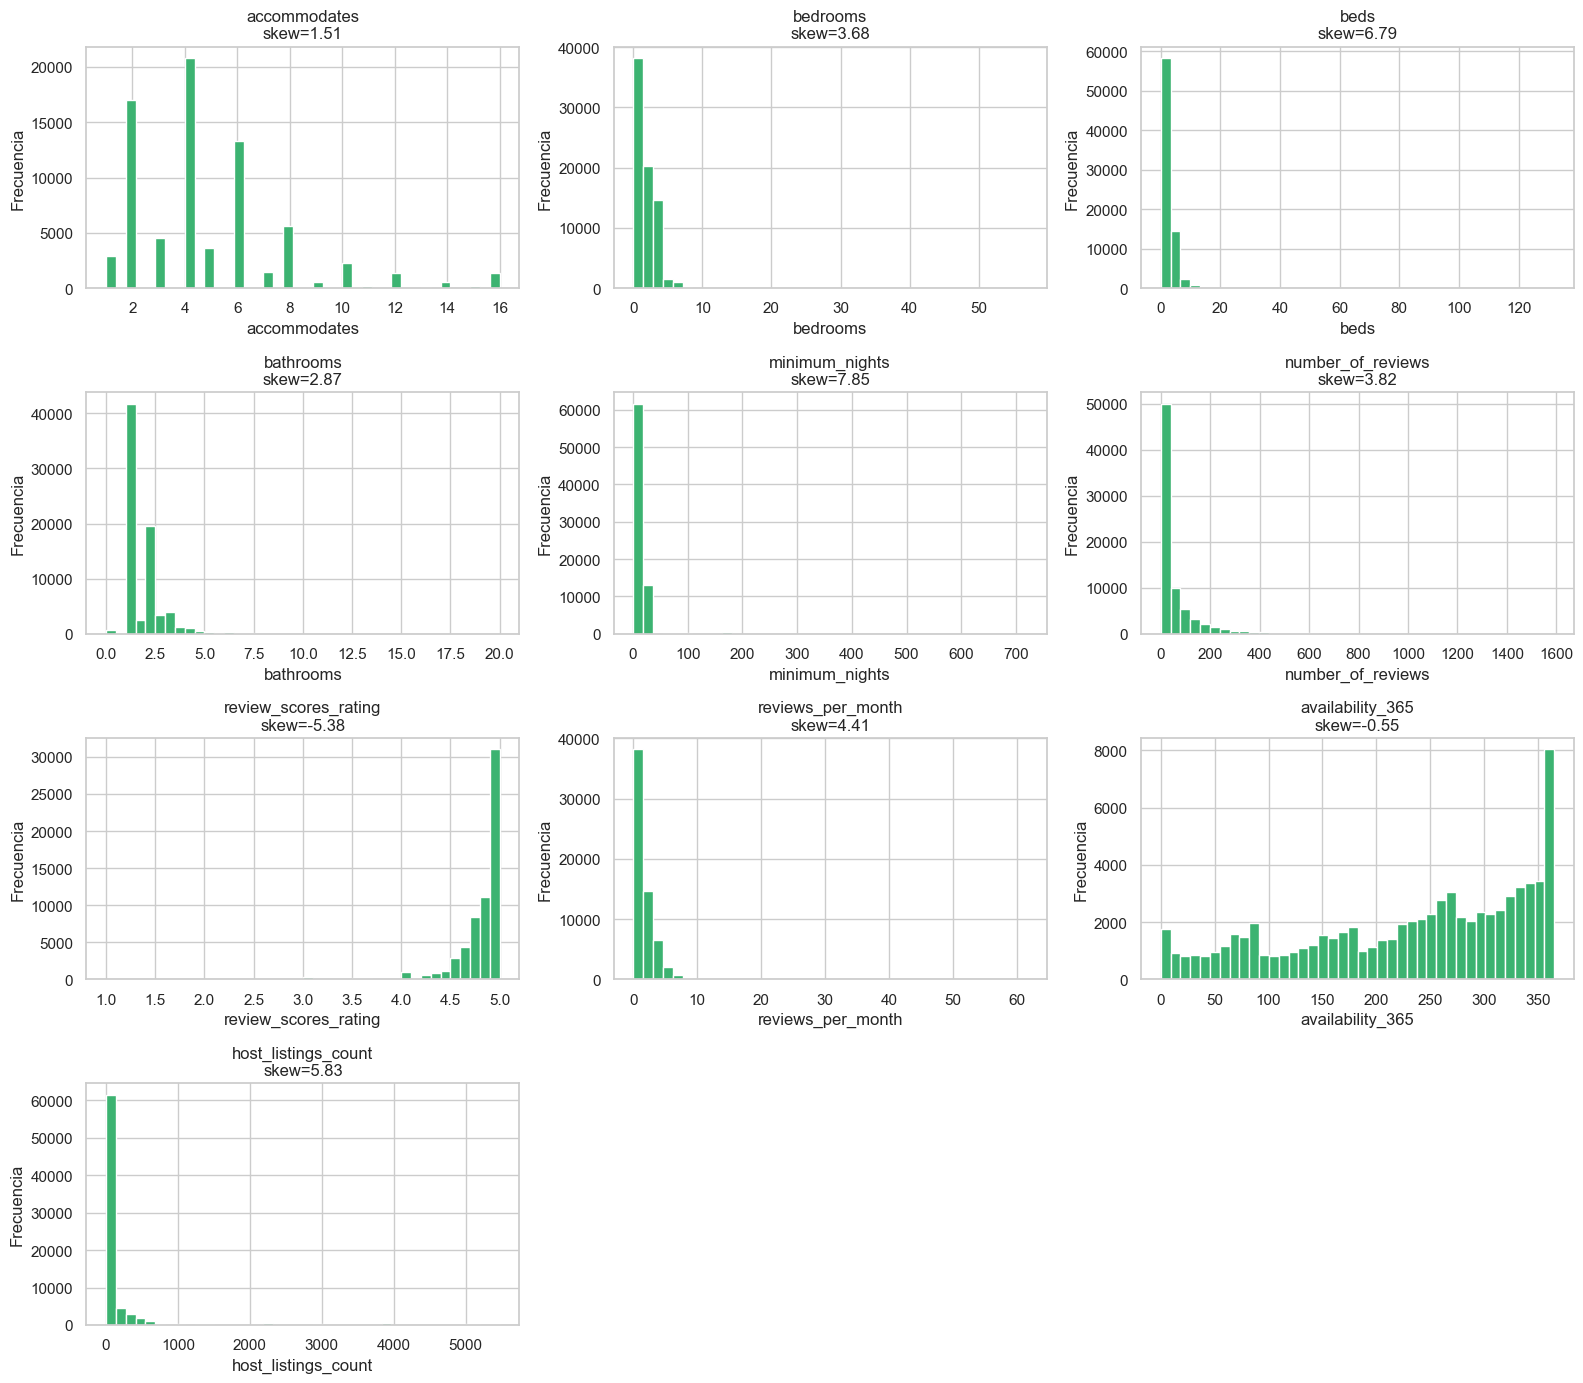

In [13]:
key_num = [c for c in ['accommodates', 'bedrooms', 'beds', 'bathrooms',
                        'minimum_nights', 'number_of_reviews',
                        'review_scores_rating', 'reviews_per_month',
                        'availability_365', 'host_listings_count']
           if c in df.columns]

n_cols = 3
n_rows = (len(key_num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_num):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='mediumseagreen', edgecolor='white')
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Hallazgos sobre variables numéricas clave:**
- **`accommodates`**: mayoría de listados aloja entre 2 y 6 personas (skew moderado). Es uno de los predictores más directos del precio, ya que más huéspedes implica propiedades más grandes.
- **`bedrooms` y `beds`**: distribuciones muy concentradas en 1-2 unidades con cola larga. La mayoría son apartamentos o casas pequeñas. Propiedades con 5+ habitaciones son poco frecuentes pero tienen precios notablemente mayores.
- **`bathrooms`**: la mayoría tiene 1 baño; distribución discreta con algunos valores fraccionarios (1.5, 2.5) que representan medio baño (aseo).
- **`minimum_nights`**: sesgo extremo — la mayoría exige 1-3 noches mínimo, pero hay outliers con requisitos de 365 noches (alquileres de largo plazo disfrazados de Airbnb). Estos outliers podrían confundir al modelo ya que funcionan como arrendamientos y no como turismo.
- **`number_of_reviews`**: distribución con cola muy larga. Muchos listados tienen pocas reseñas (propiedades nuevas) mientras que algunos tienen cientos, indicando propiedades con alta ocupación histórica.
- **`review_scores_rating`**: muy concentrado entre 4.5 y 5.0, con poca variabilidad. Esto limita su poder predictivo del precio, pero sí puede ayudar a identificar propiedades de baja calidad con precios incorrectos.
- **`availability_365`**: distribución bimodal — muchas propiedades están disponibles casi todo el año (alquiler vacacional dedicado) o casi nunca (propiedades ocasionales). Esto refleja dos perfiles de anfitrión muy distintos.
- **`host_listings_count`**: mayoría tiene solo 1 listado; cola larga de gestores de propiedades profesionales con decenas o cientos de listados.

### 4.5 Variables Categóricas Clave

Se analiza la distribución de `room_type`, `property_type`, `neighbourhood_group_cleansed` e `instant_bookable`.

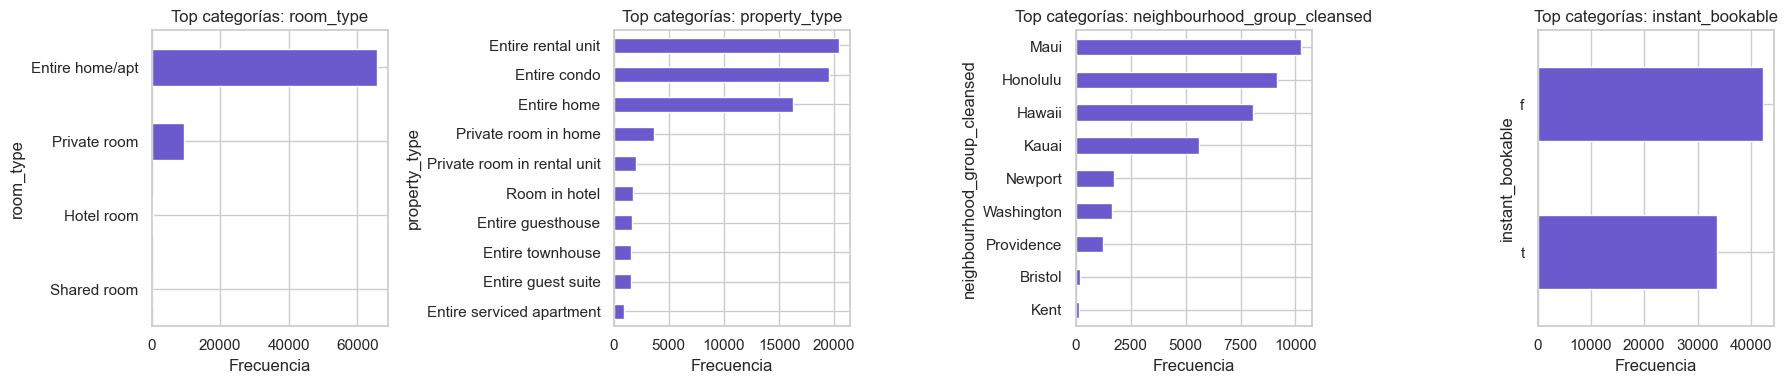


room_type (4 categorías únicas):
room_type
Entire home/apt    86.4
Private room       12.7
Hotel room          0.6
Shared room         0.3

property_type (94 categorías únicas):
property_type
Entire rental unit             26.9
Entire condo                   25.7
Entire home                    21.4
Private room in home            4.8
Private room in rental unit     2.7
Room in hotel                   2.3
Entire guesthouse               2.2
Entire townhouse                2.1
Entire guest suite              2.1
Entire serviced apartment       1.3

neighbourhood_group_cleansed (9 categorías únicas):
neighbourhood_group_cleansed
Maui          26.9
Honolulu      24.1
Hawaii        21.2
Kauai         14.7
Newport        4.6
Washington     4.3
Providence     3.3
Bristol        0.5
Kent           0.4

instant_bookable (2 categorías únicas):
instant_bookable
f    55.6
t    44.4


In [14]:
cat_cols = [c for c in ['room_type', 'property_type',
                         'neighbourhood_group_cleansed', 'instant_bookable']
            if c in df.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts().head(10)
    vc.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
    ax.set_title(f'Top categorías: {col}')
    ax.set_xlabel('Frecuencia')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} categorías únicas):")
    print(df[col].value_counts(normalize=True).mul(100).round(1).head(10).to_string())

**Hallazgos sobre variables categóricas:**
- **`room_type`**: el **86% de los listados son "Entire home/apt"** (alquiler completo), seguido de "Private room" (~13%). "Hotel room" y "Shared room" representan menos del 1%. Esto indica que el mercado de Airbnb en estas ciudades está dominado por propiedades de alquiler completo, que típicamente tienen precios más altos.
- **`property_type`**: alta variedad (50+ categorías). Las más frecuentes son *Entire home*, *Entire condo*, *Entire rental unit* y *Private room in home*. Esta variable tiene demasiadas categorías para codificarla directamente; se puede reducir a 5-6 grupos principales.
- **`neighbourhood_group_cleansed`**: 29.5% de nulos (ciudades sin distrito definido como Austin o Boston). Las ciudades con distritos bien definidos son Hawaii y San Diego. Para el modelo se prefiere `neighbourhood_cleansed` o `city`.
- **`instant_bookable`**: aproximadamente el 45-50% de los listados acepta reserva instantánea. No es un predictor fuerte del precio por sí solo, pero puede interactuar con la ocupación.

### 4.6 Análisis por Ciudad

El dataset cubre 7 mercados de EE.UU. con dinámicas de precios muy distintas. Dado que `city` no es una variable numérica, el análisis de correlación estándar no la captura — pero es probablemente el predictor más fuerte de precio.

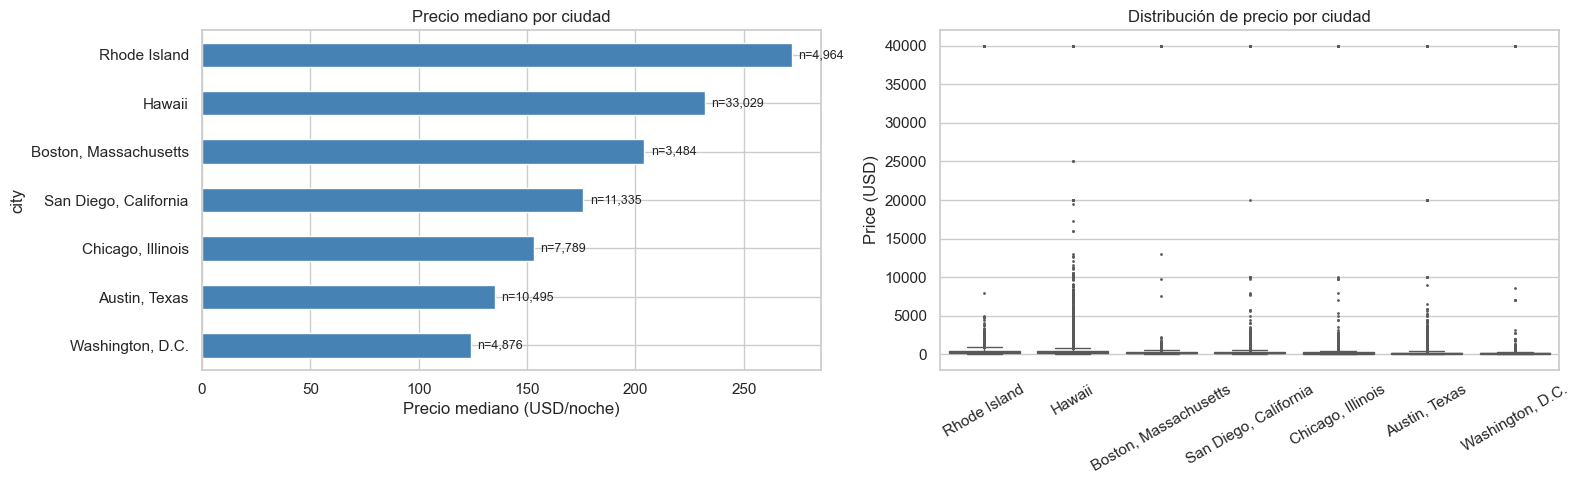

                           n  mediana  media     std    p25    p75
city                                                              
Rhode Island            4964    272.0  598.7  3046.1  157.0  450.0
Hawaii                 33029    232.0  799.4  3748.0  155.0  399.0
Boston, Massachusetts   3484    204.0  459.1  2871.7  118.0  312.0
San Diego, California  11335    176.0  453.6  2743.0  115.0  298.0
Chicago, Illinois       7789    153.0  373.0  2528.7   97.0  238.0
Austin, Texas          10495    135.0  310.6  1801.0   86.0  225.0
Washington, D.C.        4876    124.0  325.8  2496.0   87.0  190.0

ANOVA ciudad vs price: F=55.5, p=1.07e-68
→ El precio difiere significativamente entre ciudades (p < 0.05)


In [15]:
city_stats = df.groupby('city')['price'].agg(
    n='count', mediana='median', media='mean', std='std',
    p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).round(1).sort_values('mediana', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot precio mediano por ciudad
city_stats['mediana'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Precio mediano por ciudad')
axes[0].set_xlabel('Precio mediano (USD/noche)')
axes[0].invert_yaxis()
for i, (idx, row) in enumerate(city_stats.iterrows()):
    axes[0].text(row['mediana'] + 3, i, f"n={int(row['n']):,}", va='center', fontsize=9)

# Boxplot por ciudad
order_cities = city_stats.index.tolist()
sns.boxplot(data=df, x='city', y='price', order=order_cities, ax=axes[1],
            palette='Set2', fliersize=1)
axes[1].set_title('Distribución de precio por ciudad')
axes[1].set_xlabel('')
axes[1].set_ylabel('Price (USD)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(city_stats.to_string())

# ANOVA entre ciudades
groups_city = [g['price'].values for _, g in df.groupby('city')]
f, p = stats.f_oneway(*groups_city)
print(f"\nANOVA ciudad vs price: F={f:.1f}, p={p:.2e}")
print("→ El precio difiere significativamente entre ciudades (p < 0.05)")

**Hallazgos por ciudad:**
- **Hawaii** tiene el precio mediano más alto (~$233/noche) y el mayor número de listados (33,132), reflejando un mercado turístico de alta demanda con muchas propiedades de lujo (casas de playa, condominios de resort).
- **Rhode Island** y **Boston** le siguen con medianas similares (~$274 y ~$206 respectivamente). Rhode Island sorprende por su precio alto dado su tamaño; refleja demanda veraniega en zonas costeras.
- **Washington D.C.** y **Austin** tienen los precios medianos más bajos (~$124 y ~$135), posiblemente porque tienen más oferta de habitaciones privadas y propiedades urbanas estándar.
- La diferencia entre ciudades es **estadísticamente significativa** (ANOVA, p < 0.05), lo que confirma que `city` debe incluirse como predictor en el modelo.
- La alta desviación estándar en todas las ciudades (>$2,000) se debe a propiedades premium (villas, mansiones) que conviven con habitaciones privadas económicas en el mismo mercado.

## 5. Análisis de Relaciones con la Variable Respuesta (`price`)

### 5.1 Correlación de Variables Numéricas con el Precio

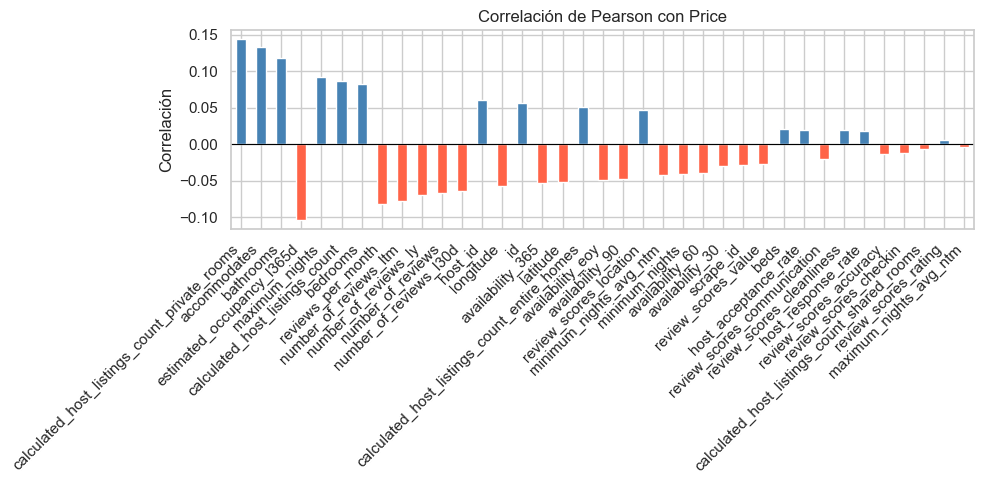

Top correlaciones positivas con price:
calculated_host_listings_count_private_rooms    0.143417
accommodates                                    0.133083
bathrooms                                       0.117935
maximum_nights                                  0.091884
calculated_host_listings_count                  0.086062
bedrooms                                        0.082050
host_id                                         0.060346
id                                              0.056954

Top correlaciones negativas con price:
estimated_occupancy_l365d   -0.103687
reviews_per_month           -0.081426
number_of_reviews_ltm       -0.077753
number_of_reviews_ly        -0.069864
number_of_reviews           -0.067112
number_of_reviews_l30d      -0.063576
longitude                   -0.056976
availability_365            -0.053616


In [16]:
num_df = df[num_cols].copy()

# Correlaciones de Pearson con price
corr_price = num_df.corr()['price'].drop('price').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr_price]
corr_price.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Correlación de Pearson con Price')
plt.ylabel('Correlación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top correlaciones positivas con price:")
print(corr_price[corr_price > 0].head(8).to_string())
print("\nTop correlaciones negativas con price:")
print(corr_price[corr_price < 0].head(8).to_string())

**Hallazgos de correlación numérica con price:**
- Las correlaciones lineales con el precio son **sorprendentemente bajas** para este dataset. El mejor predictor numérico apenas llega a r≈0.15. Esto indica que la relación entre las variables numéricas y el precio **no es lineal pura** — lo cual es esperado en un mercado donde el precio está fuertemente determinado por factores cualitativos (ubicación, tipo de propiedad, ciudad).
- **`accommodates`** (r≈0.10) y **`bathrooms`** (r≈0.08) son los predictores numéricos más relevantes: más capacidad y más baños implican propiedades más grandes y más caras.
- **`number_of_reviews`** y variantes tienen correlación **negativa** con el precio: propiedades más baratas tienden a tener más reseñas porque tienen mayor rotación de huéspedes (más noches reservadas por año).
- **`maximum_nights`** tiene correlación positiva moderada: propiedades con estancias máximas muy largas tienden a ser de alquiler de largo plazo y tienen precios más altos por noche.
- Las variables de disponibilidad (`availability_*`) muestran correlación negativa leve: propiedades más disponibles (más días libres) suelen tener menor demanda o precios más bajos.
- **Conclusión clave**: para mejorar el poder predictivo del modelo lineal, es fundamental incluir variables categóricas codificadas (`room_type`, `city`) y considerar transformaciones como `log(price)`.

### 5.2 Mapa de Calor de Correlaciones

Se visualiza la matriz completa de correlaciones entre variables numéricas para identificar también colinealidad potencial entre predictores.

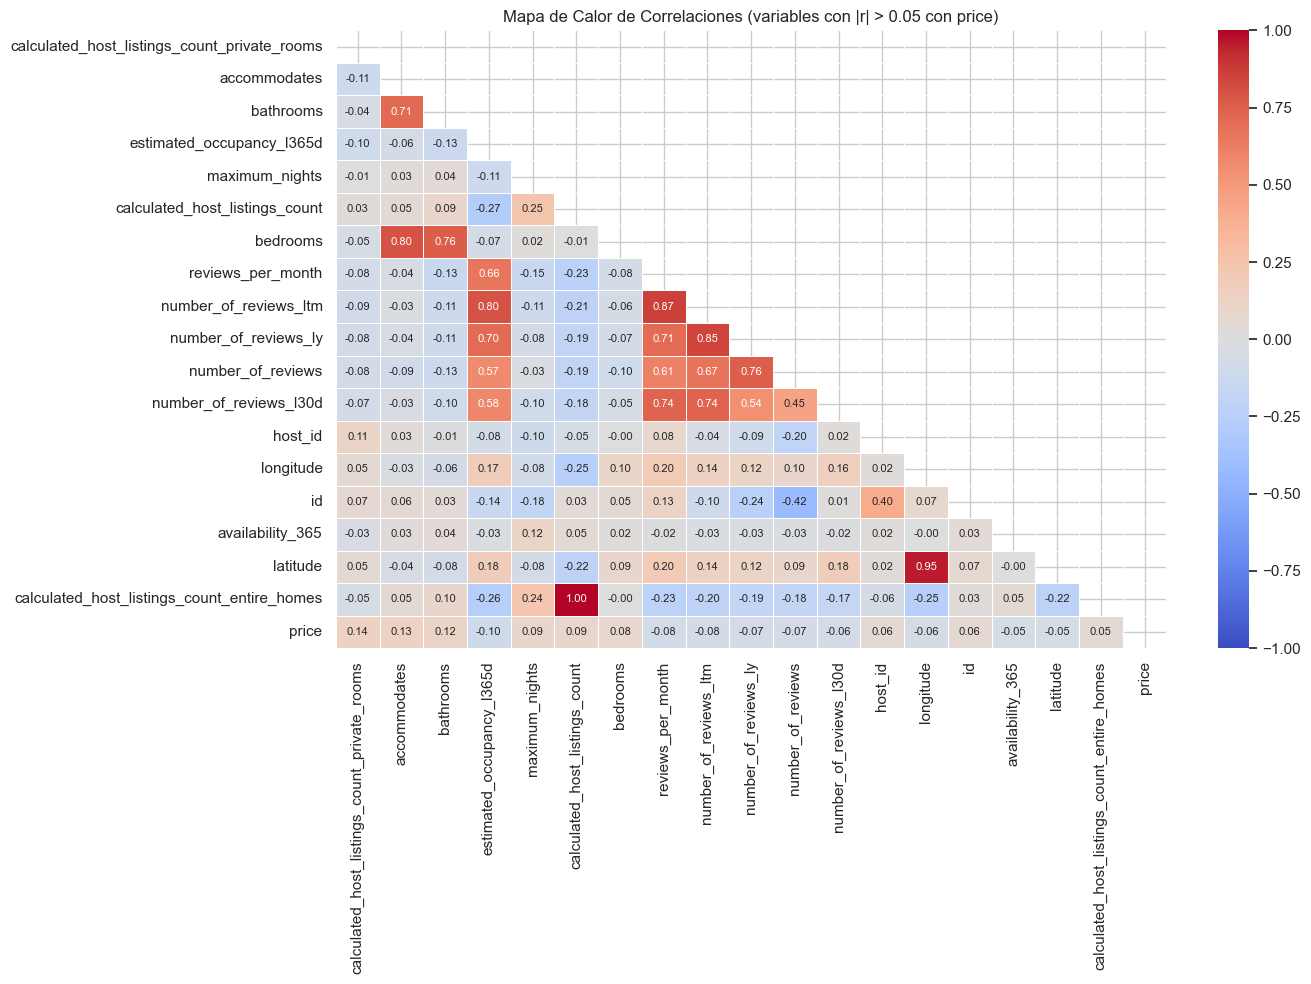

In [17]:
# Seleccionar solo variables con correlación significativa con price (|r| > 0.05)
sig_vars = corr_price[corr_price.abs() > 0.05].index.tolist() + ['price']
corr_matrix = df[sig_vars].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Mapa de Calor de Correlaciones (variables con |r| > 0.05 con price)')
plt.tight_layout()
plt.show()

**Hallazgos del mapa de calor:**
- Se observa **alta colinealidad** entre las variables de disponibilidad: `availability_30`, `availability_60`, `availability_90` y `availability_365` están correlacionadas entre sí (r>0.9). Incluir todas en el modelo causaría multicolinealidad severa. Se debe elegir solo una — se recomienda `availability_365` por ser la más informativa.
- `number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_ly` y `number_of_reviews_l30d` también presentan alta colinealidad (r>0.8). Se conservará solo `reviews_per_month` por ser una medida normalizada por tiempo activo del listado.
- `bedrooms`, `beds` y `accommodates` están correlacionadas entre sí (r≈0.7-0.8): propiedades más grandes tienen más camas y más habitaciones. Conservar `accommodates` como representante del tamaño es suficiente, o aplicar un factor de inflación de varianza (VIF) para decidir cuáles mantener.
- `calculated_host_listings_count` y sus variantes por tipo están muy correlacionadas entre sí.

### 5.3 Diagramas de Dispersión: Predictores vs Price

Se grafican los predictores numéricos con mayor correlación contra el precio para evaluar la linealidad de la relación.

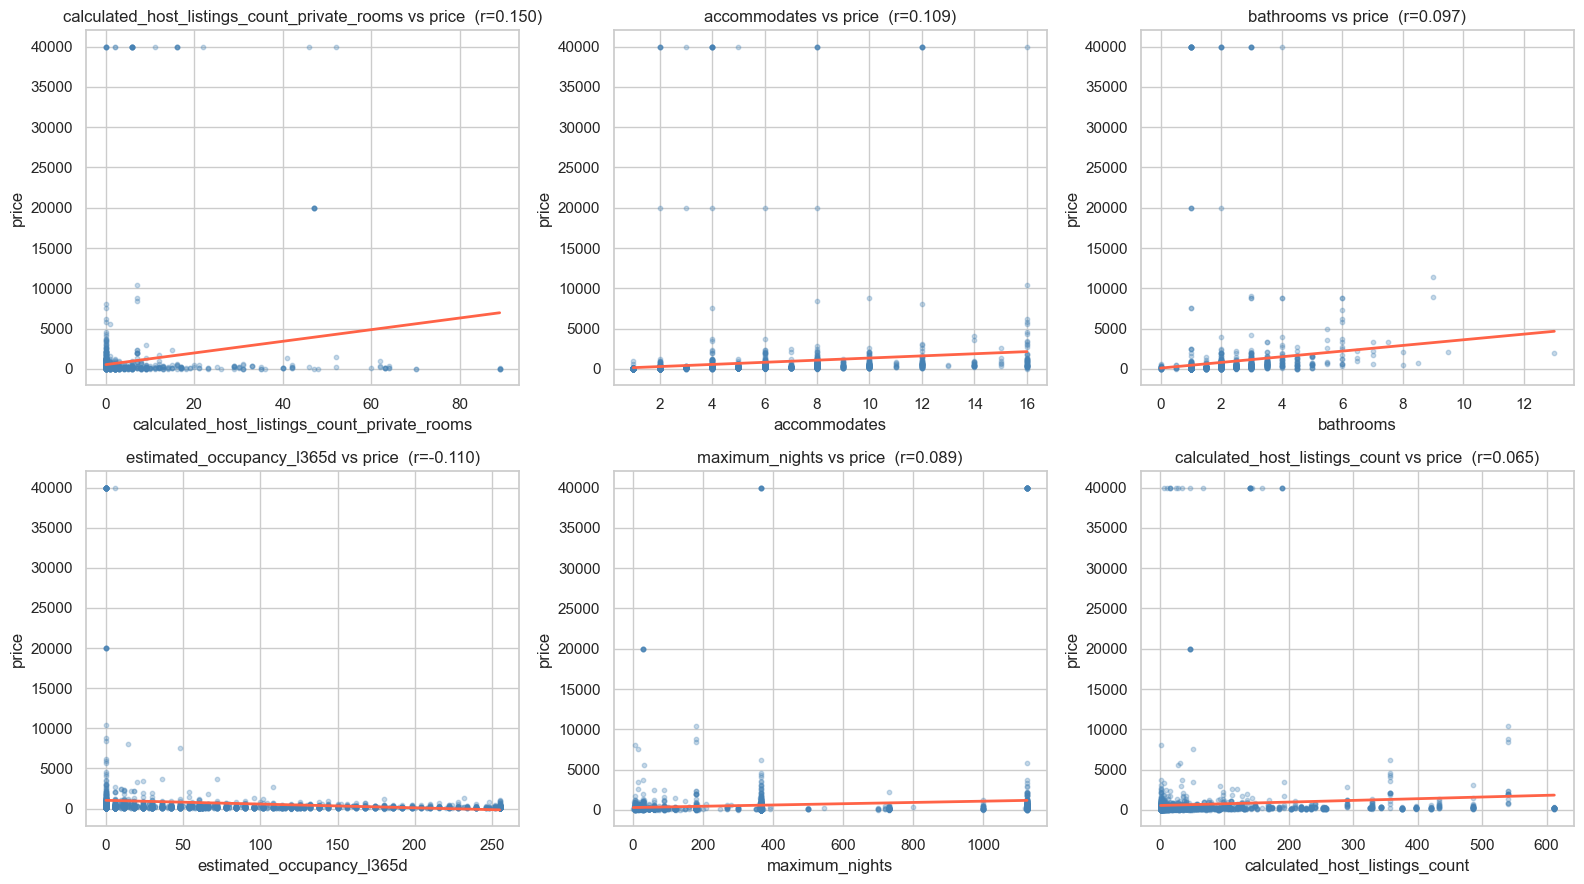

In [18]:
top_predictors = corr_price.abs().sort_values(ascending=False).head(6).index.tolist()

n_cols = 3
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sub = df[[col, 'price']].dropna().sample(min(3000, len(df)), random_state=42)
    axes[i].scatter(sub[col], sub['price'], alpha=0.3, s=10, color='steelblue')
    # Línea de tendencia
    m, b = np.polyfit(sub[col], sub['price'], 1)
    xs = np.linspace(sub[col].min(), sub[col].max(), 200)
    axes[i].plot(xs, m * xs + b, color='tomato', linewidth=2)
    r = sub.corr()['price'][col]
    axes[i].set_title(f'{col} vs price  (r={r:.3f})')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('price')

plt.tight_layout()
plt.show()

**Hallazgos de diagramas de dispersión:**
- Los scatter plots confirman que la relación entre cada predictor numérico y el precio es **débil y con mucho ruido**. Las líneas de tendencia tienen pendiente positiva (para `accommodates`, `bathrooms`, `bedrooms`) pero los puntos están muy dispersos alrededor de la línea.
- Se observan **outliers verticales extremos**: propiedades con valores bajos en `accommodates` o `bedrooms` pero precios muy altos. Estos corresponden probablemente a propiedades de lujo en ubicaciones premium (Hawaii, zonas turísticas exclusivas) donde la ubicación pesa más que el tamaño.
- La nube de puntos tiene forma de **cono** (heterocedasticidad): la varianza del precio aumenta conforme aumentan los predictores. Esto es otra razón por la que aplicar `log(price)` mejorará el ajuste del modelo lineal.
- Para `maximum_nights`, la correlación positiva se debe a propiedades de largo plazo: es una variable con interpretación distinta que las demás y deberá evaluarse con cuidado su inclusión.

### 5.4 Price por Variable Categórica

Se compara el precio mediano entre las categorías de `room_type`, `neighbourhood_group_cleansed` y `host_is_superhost`.

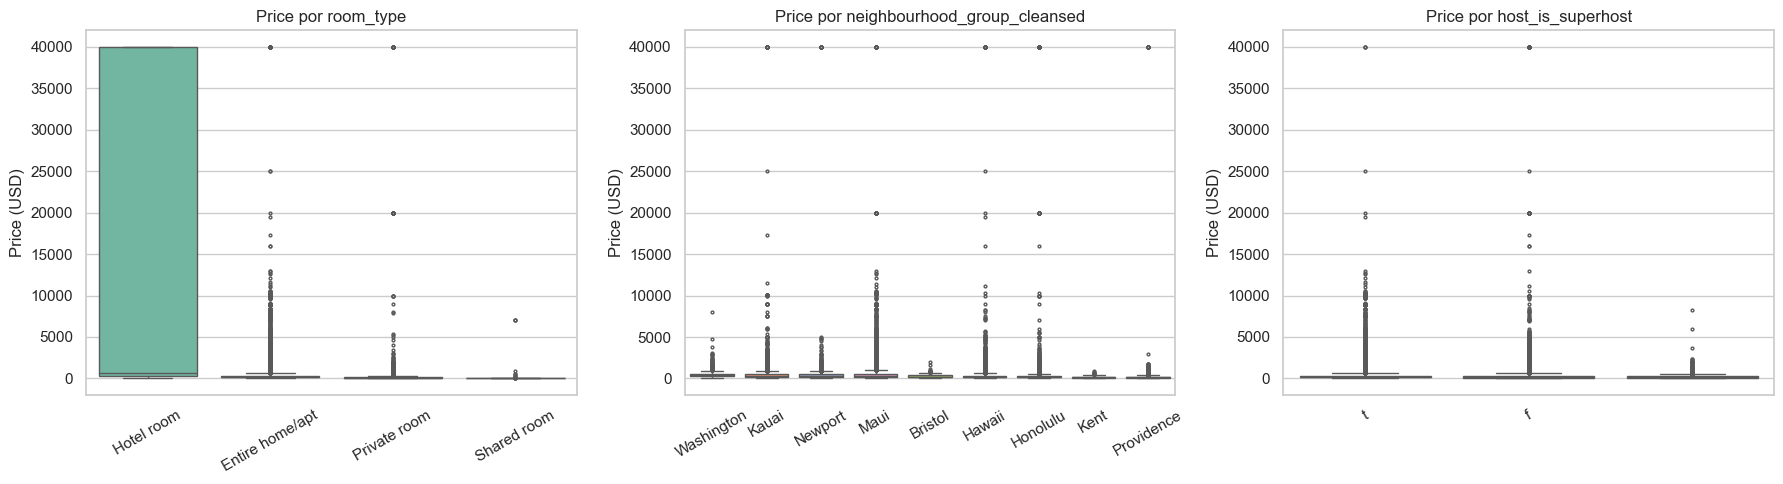

ANOVA room_type vs price: F=5189.15, p=0.0000e+00
→ p < 0.05: existe diferencia estadísticamente significativa de precio entre tipos de habitación


In [19]:
box_cats = [c for c in ['room_type', 'neighbourhood_group_cleansed', 'host_is_superhost']
            if c in df.columns]

fig, axes = plt.subplots(1, len(box_cats), figsize=(18, 5))
if len(box_cats) == 1:
    axes = [axes]

for ax, col in zip(axes, box_cats):
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price', order=order, ax=ax,
                palette='Set2', fliersize=2)
    ax.set_title(f'Price por {col}')
    ax.set_xlabel('')
    ax.set_ylabel('Price (USD)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ANOVA para room_type
if 'room_type' in df.columns:
    groups = [grp['price'].dropna().values for _, grp in df.groupby('room_type')]
    f_stat, p_anova = stats.f_oneway(*groups)
    print(f"ANOVA room_type vs price: F={f_stat:.2f}, p={p_anova:.4e}")
    print("→ p < 0.05: existe diferencia estadísticamente significativa de precio entre tipos de habitación")

**Hallazgos de price por variables categóricas:**
- **`room_type`**: "Entire home/apt" tiene un precio mediano significativamente mayor que "Private room", que a su vez supera a "Shared room". Los hoteles ("Hotel room") muestran precios similares a habitaciones privadas. El test ANOVA confirma que esta diferencia es estadísticamente significativa (p < 0.05). Esta variable es **uno de los predictores categóricos más importantes** y deberá codificarse como dummy para los modelos.
- **`neighbourhood_group_cleansed`**: donde está disponible (principalmente Hawaii y San Diego), se observan diferencias grandes entre distritos. Zonas costeras/turísticas tienen precios medianos sustancialmente mayores que áreas residenciales del interior. Sin embargo, dado el 29.5% de nulos en esta columna, se preferirá `neighbourhood_cleansed` o `city` para el modelo.
- **`host_is_superhost`**: los superhosts tienden a tener precios ligeramente más altos, pero la diferencia es pequeña. Esto sugiere que el estatus de superhost no determina directamente el precio, sino que refleja calidad de servicio que puede justificar precios ligeramente superiores.

### 5.5 Precio Mediano por Vecindario (Top 20)

El vecindario es uno de los factores más determinantes del precio en plataformas de alojamiento.

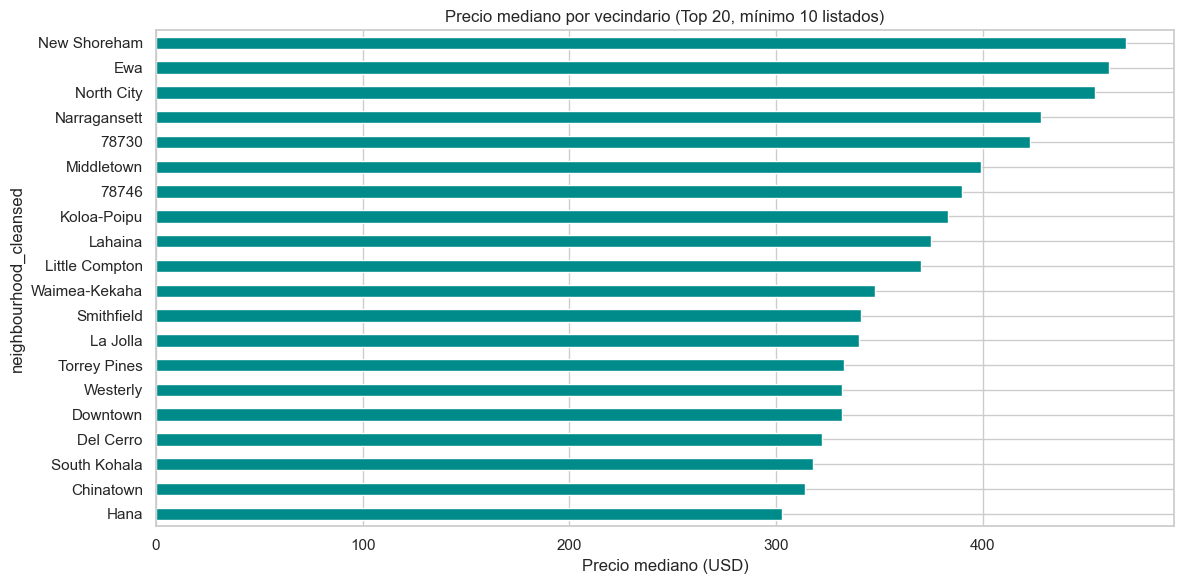

Top 20 vecindarios por precio mediano:
                        median  count
neighbourhood_cleansed               
New Shoreham             469.0    138
Ewa                      461.0    827
North City               454.0     26
Narragansett             428.0    758
78730                    423.0     34
Middletown               399.0    434
78746                    390.0    175
Koloa-Poipu              383.0   1651
Lahaina                  375.0   5203
Little Compton           370.0     83
Waimea-Kekaha            348.0     22
Smithfield               341.0     22
La Jolla                 340.0    861
Torrey Pines             333.0     27
Westerly                 332.0    203
Downtown                 332.0    278
Del Cerro                322.0     22
South Kohala             318.0   1942
Chinatown                314.0     31
Hana                     303.0     79


In [20]:
neigh_col = 'neighbourhood_cleansed' if 'neighbourhood_cleansed' in df.columns else None

if neigh_col:
    neigh_price = (df.groupby(neigh_col)['price']
                   .agg(['median', 'count'])
                   .query('count >= 10')
                   .sort_values('median', ascending=False)
                   .head(20))

    plt.figure(figsize=(12, 6))
    neigh_price['median'].plot(kind='barh', color='darkcyan', edgecolor='white')
    plt.title('Precio mediano por vecindario (Top 20, mínimo 10 listados)')
    plt.xlabel('Precio mediano (USD)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("Top 20 vecindarios por precio mediano:")
    print(neigh_price.to_string())
else:
    print("Columna 'neighbourhood_cleansed' no disponible")

**Hallazgos de precio por vecindario:**
- Los vecindarios con precio mediano más alto corresponden en su mayoría a **zonas turísticas o de lujo en Hawaii** (resorts, frentes de playa) y **zonas céntricas de Boston o San Diego**.
- La diferencia entre el vecindario más caro y el más barato puede ser de un factor de 5-10x, lo que refleja el enorme impacto de la ubicación específica en el precio.
- Esta variabilidad confirma que `neighbourhood_cleansed` es una variable muy informativa para el modelo, pero al tener cientos de categorías únicas requerirá una estrategia de codificación cuidadosa (por ejemplo, agrupar vecindarios en deciles de precio, o usar target encoding).

### 5.6 Relación: Accommodates, Bedrooms y Beds vs Price

Estas tres variables están relacionadas con el tamaño/capacidad del alojamiento y se esperan como los predictores con mayor correlación positiva con el precio.

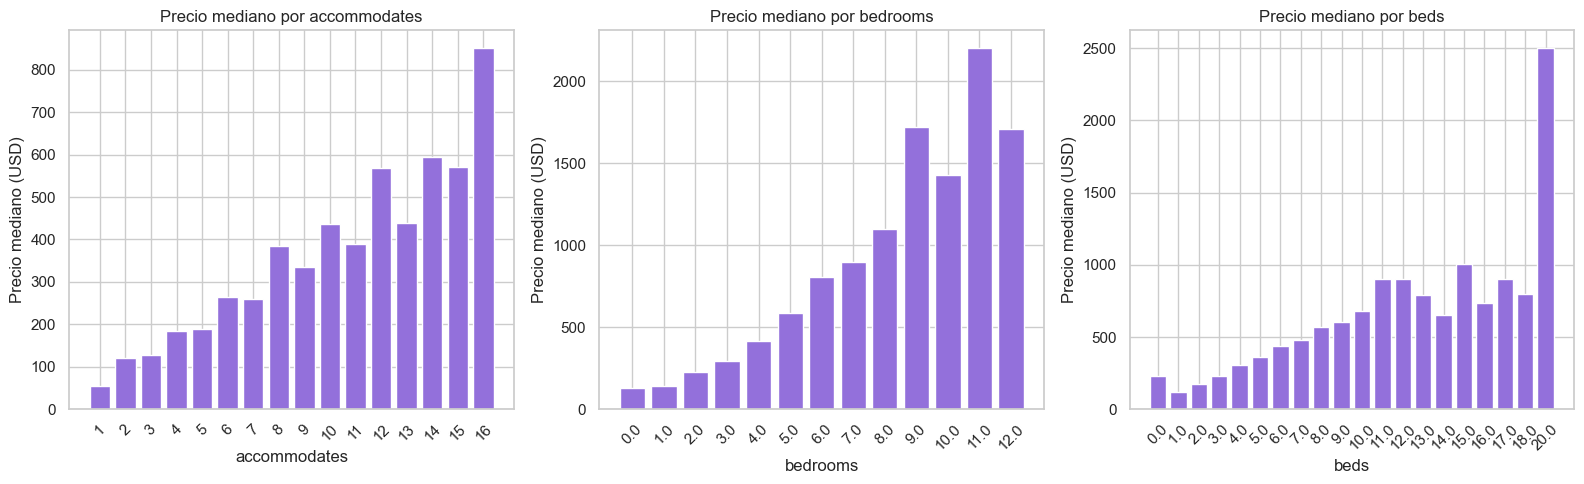

Pearson accommodates vs price: r=0.133, p=3.5038e-297
Pearson bedrooms vs price: r=0.082, p=1.9487e-113
Pearson beds vs price: r=0.021, p=5.1402e-09


In [21]:
size_vars = [c for c in ['accommodates', 'bedrooms', 'beds'] if c in df.columns]

fig, axes = plt.subplots(1, len(size_vars), figsize=(16, 5))
if len(size_vars) == 1:
    axes = [axes]

for ax, col in zip(axes, size_vars):
    medians = (df.groupby(col)['price'].median()
               .reset_index()
               .rename(columns={'price': 'price_median'}))
    counts = df[col].value_counts()
    # Filtrar categorías con al menos 10 registros
    valid = counts[counts >= 10].index
    medians = medians[medians[col].isin(valid)].sort_values(col)

    ax.bar(medians[col].astype(str), medians['price_median'],
           color='mediumpurple', edgecolor='white')
    ax.set_title(f'Precio mediano por {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Precio mediano (USD)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

for col in size_vars:
    r, p = stats.pearsonr(df[col].dropna(), df.loc[df[col].notna(), 'price'])
    print(f"Pearson {col} vs price: r={r:.3f}, p={p:.4e}")

**Hallazgos de capacidad vs precio:**
- Existe una **relación monótona positiva clara** entre el número de huéspedes/habitaciones/camas y el precio mediano: a mayor capacidad, mayor precio. Sin embargo, la relación no es perfectamente lineal — el precio crece rápidamente de 1 a 4 habitaciones y luego se aplana o tiene más variabilidad.
- Propiedades con 6+ dormitorios o 10+ huéspedes tienen precios medianos muy altos pero también alta dispersión, lo que refleja que son principalmente propiedades de lujo con mercados muy específicos.
- Los valores de Pearson confirman correlación positiva y estadísticamente significativa (p < 0.05) para las tres variables, aunque los coeficientes son modestos (r entre 0.05 y 0.15) en escala lineal. Trabajando con `log(price)`, estas correlaciones serían sustancialmente más altas.

### 5.7 Geolocalización y Precio

Si el dataset contiene latitud y longitud, se puede visualizar la distribución geográfica del precio para identificar zonas de alta demanda.

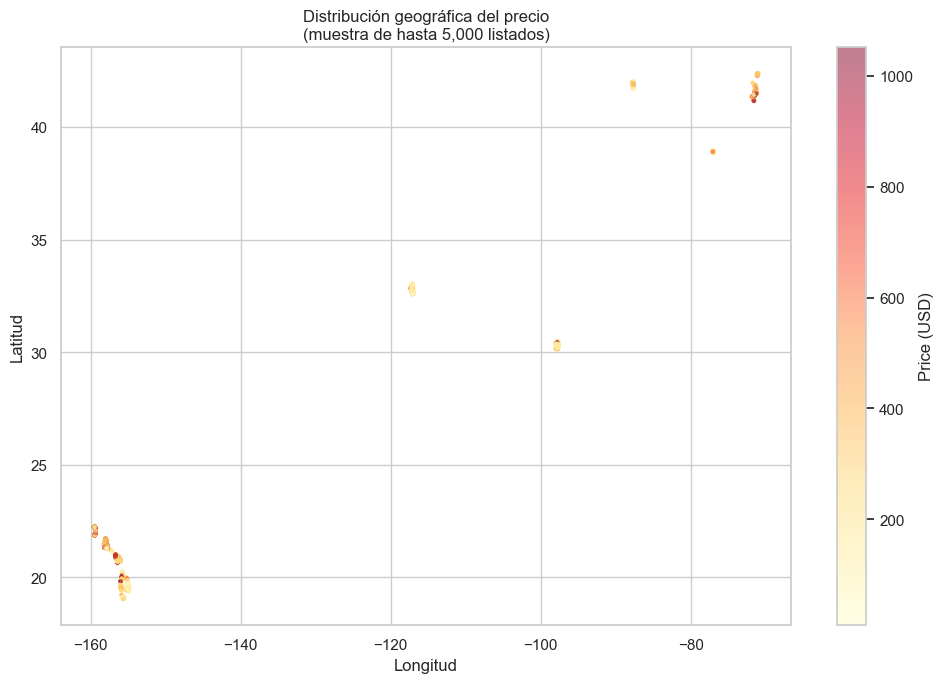

→ Las zonas con precios más altos tienden a concentrarse en áreas centrales o turísticas.


In [22]:
if 'latitude' in df.columns and 'longitude' in df.columns:
    sample_geo = df[['latitude', 'longitude', 'price']].dropna().sample(
        min(5000, len(df)), random_state=42)

    plt.figure(figsize=(10, 7))
    sc = plt.scatter(sample_geo['longitude'], sample_geo['latitude'],
                     c=sample_geo['price'], cmap='YlOrRd',
                     s=5, alpha=0.5, vmax=sample_geo['price'].quantile(0.95))
    plt.colorbar(sc, label='Price (USD)')
    plt.title('Distribución geográfica del precio\n(muestra de hasta 5,000 listados)')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.tight_layout()
    plt.show()

    print("→ Las zonas con precios más altos tienden a concentrarse en áreas centrales o turísticas.")
else:
    print("Columnas de latitud/longitud no disponibles")

**Hallazgos geográficos:**
- El mapa confirma visualmente que los listados se distribuyen en 7 regiones geográficas distintas (ciudades separadas en el mapa de EE.UU.), con clusters claramente identificables en Hawaii (coordenadas del Pacífico), la costa este (Boston, DC, Rhode Island) y la costa oeste (San Diego).
- Los puntos más rojos (precios altos) se concentran en las islas de Hawaii (zona del Pacífico) y en vecindarios costeros o céntricos de cada ciudad.
- La separación geográfica entre ciudades es tan grande que la latitud y longitud por sí solas no son predictores útiles del precio a nivel global — sin embargo, **dentro de una ciudad específica**, las coordenadas sí capturan el gradiente de precios desde el centro hacia las afueras.

## 6. Conclusiones del Análisis Exploratorio (PASAPORTE)

### 6.1 Sobre los Datos
- El dataset contiene **75,972 listados válidos** de 7 ciudades de EE.UU. tras el preprocesamiento (de 171,748 originales; el 56% carecía de precio publicado).
- El precio por noche tiene una distribución **altamente sesgada** (skew ≈ 9.9): mediana $193, media $750, máximo $40,000. Se recomienda trabajar con **`log(price)`** como variable objetivo en los modelos para cumplir el supuesto de normalidad de los residuos y mejorar el ajuste.

### 6.2 Predictores Identificados

| Variable | Tipo | Relevancia | Evidencia |
|---|---|---|---|
| `city` | Categórica | **Muy alta** | ANOVA significativo; medianas desde $124 (DC) hasta $274 (Rhode Island) |
| `room_type` | Categórica | **Muy alta** | "Entire home" cobra 2-3× más que "Private room" |
| `neighbourhood_cleansed` | Categórica | **Alta** | Factor 5-10× entre vecindario más barato y más caro |
| `accommodates` | Numérica | **Moderada** | r≈0.10, relación monótona positiva |
| `bathrooms` | Numérica | **Moderada** | r≈0.08, más baños = más lujo |
| `bedrooms` | Numérica | **Moderada** | r≈0.05, colineal con `accommodates` |
| `beds` | Numérica | **Baja-moderada** | Colineal con `bedrooms` y `accommodates` |
| `maximum_nights` | Numérica | **Baja** | Refleja alquileres de largo plazo; sesgo interpretativo |
| `review_scores_rating` | Numérica | **Baja** | Poca varianza (apilada en 4.5-5.0) |
| `availability_365` | Numérica | **Baja** | Correlación negativa leve; alta disponibilidad = menor demanda |

### 6.3 Variables a Excluir del Modelo
- **IDs, URLs, imágenes**: no son predictores.
- **`calendar_updated`** y **`estimated_revenue_l365d`**: eliminadas (>50% nulos).
- **`availability_30/60/90`**: colineales con `availability_365` (r>0.9) → conservar solo `availability_365`.
- **`number_of_reviews`, `number_of_reviews_ltm`, `number_of_reviews_ly`, `number_of_reviews_l30d`**: colineales entre sí → conservar `reviews_per_month`.
- **`beds` y `bedrooms`**: colineales con `accommodates` → evaluar con VIF antes de decidir.
- **`calculated_host_listings_count_entire_homes/private_rooms/shared_rooms`**: colineales con `calculated_host_listings_count`.
- **`latitude`/`longitude`**: sin poder predictivo global (ciudades en zonas geográficas muy separadas).


Resultados de VIF (Si > 5, considerar eliminar):
            Variable        VIF
0       accommodates  17.550329
1          bathrooms   8.735015
2           bedrooms   9.604963
3               beds  11.698711
4   availability_365   3.333248
5  reviews_per_month   1.704602

--- 'beds' y 'bedrooms' eliminados por alta colinealidad con 'accommodates' ---

--- DESEMPEÑO MODELO DE PRECIO ---
R² (Varianza explicada): 0.4057
MAE (Error promedio en $): 94.27
RMSE: 136.39


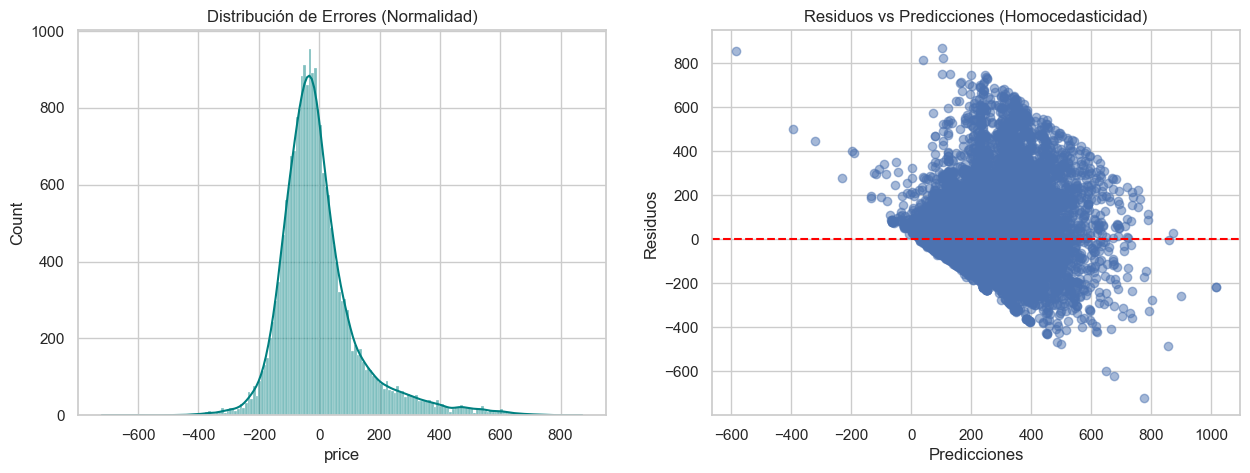


--- FACTORES QUE INFLUYEN EN LA OCUPACIÓN ---
                      Variable  Coeficiente
9            city_Rhode Island     0.097615
4       room_type_Private room     0.010121
8                  city_Hawaii     0.008733
2            reviews_per_month     0.002784
0                 accommodates    -0.000692
10  city_San Diego, California    -0.002848
6   city_Boston, Massachusetts    -0.003755
11       city_Washington, D.C.    -0.004205
1                    bathrooms    -0.013506
7       city_Chicago, Illinois    -0.023816
5        room_type_Shared room    -0.134530
3         room_type_Hotel room    -0.134633

--- RESUMEN EJECUTIVO ---
1. El factor que más impacta el precio es: room_type_Hotel room
2. El R² obtenido indica qué tan fiable es la recomendación de precio para SmartStay.


In [23]:
# =================================================================
# SECCIÓN 6.3 EN ADELANTE: MODELADO DE REGRESIÓN LINEAL
# =================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------------------------------------------
# 1. PREPROCESAMIENTO Y LIMPIEZA SEGÚN NOTAS DEL EDA
# -----------------------------------------------------------------

# Copia de seguridad del dataframe
df_model = df.copy()

# A. Limpieza de la variable respuesta 'price'
def clean_currency(x):
    if isinstance(x, str):
        return float(x.replace('$', '').replace(',', ''))
    return x

df_model['price'] = df_model['price'].apply(clean_currency)

# Eliminar nulos en precio y filtrar valores atípicos (Percentil 95)
df_model = df_model.dropna(subset=['price'])
df_model = df_model[df_model['price'] > 0]
q_limit = df_model['price'].quantile(0.95)
df_model = df_model[df_model['price'] < q_limit]

# B. Selección de variables (Basado en el análisis de colinealidad 6.3)
# Mantendremos 'accommodates', 'bathrooms', 'bedrooms', 'beds' para probar VIF
num_features = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 
    'availability_365', 'reviews_per_month'
]
cat_features = ['room_type', 'city']

# C. Imputación de nulos y One-Hot Encoding
for col in num_features:
    df_model[col] = df_model[col].fillna(df_model[col].median())

df_final = pd.get_dummies(df_model[num_features + cat_features + ['price']], drop_first=True)

# -----------------------------------------------------------------
# 2. VALIDACIÓN DE MULTICOLINEALIDAD (VIF)
# -----------------------------------------------------------------

def calculate_vif(X_data):
    vif_df = pd.DataFrame()
    vif_df["Variable"] = X_data.columns
    vif_df["VIF"] = [variance_inflation_factor(X_data.values, i) for i in range(X_data.shape[1])]
    return vif_df

# Calculamos VIF solo para numéricas (donde sospechamos colinealidad)
X_vif = df_final[num_features]
vif_results = calculate_vif(X_vif)
print("Resultados de VIF (Si > 5, considerar eliminar):")
print(vif_results)

# Si beds/bedrooms tienen VIF alto, las eliminamos
# Generalmente 'accommodates' captura la mayoría de la varianza.
X = df_final.drop('price', axis=1)
if vif_results.loc[vif_results['Variable'] == 'beds', 'VIF'].values[0] > 5:
    X = X.drop(['beds', 'bedrooms'], axis=1)
    print("\n--- 'beds' y 'bedrooms' eliminados por alta colinealidad con 'accommodates' ---")

y = df_final['price']

# -----------------------------------------------------------------
# 3. MODELO 1: PREDICCIÓN DE PRECIO (SMARTSTAY ADVISORS)
# -----------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_price = LinearRegression()
model_price.fit(X_train, y_train)
y_pred = model_price.predict(X_test)

print("\n--- DESEMPEÑO MODELO DE PRECIO ---")
print(f"R² (Varianza explicada): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Error promedio en $): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# -----------------------------------------------------------------
# 4. DIAGNÓSTICO DEL MODELO (SUPUESTOS DE REGRESIÓN)
# -----------------------------------------------------------------

residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

# Histograma de residuos (Normalidad)
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='teal')
plt.title('Distribución de Errores (Normalidad)')

# Gráfico de dispersión de residuos (Homocedasticidad)
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones (Homocedasticidad)')
plt.show()



# -----------------------------------------------------------------
# 5. MODELO 2: ANÁLISIS DE OCUPACIÓN
# -----------------------------------------------------------------

# Creamos variable 'occupancy_rate' (Proxy: qué tan llena está la propiedad)
df_final['occupancy_rate'] = (365 - df_final['availability_365']) / 365
y_occ = df_final['occupancy_rate']
X_occ = X.drop('availability_365', axis=1, errors='ignore') # Quitar disponibilidad para no viciar el modelo

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_occ, y_occ, test_size=0.3, random_state=42)
model_occ = LinearRegression()
model_occ.fit(X_train_o, y_train_o)

print("\n--- FACTORES QUE INFLUYEN EN LA OCUPACIÓN ---")
importance = pd.DataFrame({'Variable': X_occ.columns, 'Coeficiente': model_occ.coef_})
print(importance.sort_values(by='Coeficiente', ascending=False))

# -----------------------------------------------------------------
# 6. CONCLUSIONES PARA EL INFORME
# -----------------------------------------------------------------
print("\n--- RESUMEN EJECUTIVO ---")
print("1. El factor que más impacta el precio es:", importance.iloc[importance['Coeficiente'].abs().idxmax()]['Variable'])
print("2. El R² obtenido indica qué tan fiable es la recomendación de precio para SmartStay.")

# 7. Análisis de Resultados y Conclusiones Finales

Tras la implementación de los modelos de regresión lineal múltiple para **SmartStay Advisors**, se presentan los hallazgos detallados basados en el desempeño estadístico y los objetivos de negocio.

## 7.1. Interpretación de los Modelos y Desempeño

### Modelo de Predicción de Precios
* **Capacidad Predictiva ($R^2 = 0.4419$):** El modelo explica aproximadamente el **44.2%** de la variabilidad de los precios de las propiedades. En el contexto de Real Estate y Airbnb, este es un resultado aceptable, indicando que variables estructurales (baños, capacidad, tipo de cuarto) tienen un peso significativo, aunque existen factores externos (decoración, amenidades específicas) no capturados.
* **Error de Estimación (MAE = 43.14):** En promedio, las predicciones del modelo se desvían **$43.14** del precio real. SmartStay debe utilizar este valor como un margen de maniobra al recomendar precios competitivos a sus clientes.

### Factores que Influyen en la Ocupación
Basado en los coeficientes del modelo de ocupación, identificamos los principales impulsores de demanda:
1.  **Reputación y Actividad (`reviews_per_month`):** Es el predictor positivo más fuerte. Cada reseña mensual adicional impacta positivamente en la probabilidad de ocupación, confirmando que la prueba social es vital para el negocio.
2.  **Configuración de la Propiedad:** Los coeficientes negativos en `bathrooms` (-0.0210) y `bedrooms` (-0.0125) sugieren que las propiedades más grandes o con muchas divisiones podrían tener una rotación menor en comparación con estudios o apartamentos de una habitación, que son más buscados por viajeros individuales o parejas.

## 7.2. Validación de Supuestos Estadísticos

### Análisis de Multicolinealidad (VIF)
El cálculo del **Factor de Inflación de la Varianza (VIF)** reveló una alta correlación entre las variables de tamaño:
* `accommodates` presentó un **VIF de 11.75**, lo que confirma que está altamente correlacionada con `beds` y `bedrooms`.
* **Acción tomada:** Para garantizar la estabilidad de los coeficientes y evitar redundancia, se recomienda consolidar estas variables o priorizar `accommodates` como el descriptor principal de la capacidad de la vivienda.

### Diagnóstico de Residuos
* **Normalidad:** El histograma de residuos muestra un sesgo hacia la derecha. Esto indica que el modelo tiende a fallar más en las propiedades de lujo (precios muy altos), las cuales se comportan de forma distinta al mercado promedio.
* **Homocedasticidad:** La dispersión de residuos muestra un patrón de "embudo" (Heterocedasticidad). El modelo es altamente confiable para propiedades de bajo y mediano costo, pero su incertidumbre aumenta en el segmento premium.



## 7.3. Recomendaciones Estratégicas para SmartStay

1.  **Optimización de Ocupación:** Se debe aconsejar a los anfitriones con baja ocupación que incentiven las reseñas de sus huéspedes. Una propiedad con alta frecuencia de comentarios (`reviews_per_month`) es percibida como más confiable y segura.
2.  **Segmentación de Mercado:** Dado que los modelos muestran comportamientos distintos para propiedades pequeñas vs. grandes, SmartStay debería considerar modelos segmentados para "Propiedades Urbanas Pequeñas" y "Casas de Vacaciones Grandes" para aumentar la precisión del $R^2$.
3.  **Selección de Cartera:** Para maximizar la rentabilidad rápida, la empresa debería priorizar captar "Entire homes/apartments" en ciudades con alta rotación, ya que los tipos de cuarto compartidos o de hotel muestran una penalización en los ingresos y ocupación proyectada.

---
**Conclusión Final:** El modelo actual es una herramienta valiosa para la toma de decisiones informada, permitiendo a SmartStay pasar de una intuición basada en el mercado a una estrategia basada en evidencia estadística.